In [1]:
from pathlib import Path
from src.data_loader import load_all_dataset
from src.train_model import build_model_pipeline, train_model, evaluate_model

data_dir = Path("../data/raw")

dataset = load_all_dataset(data_dir)

for name, df in dataset.items():
    print(name, df.shape)

FD001 (20631, 26)
FD002 (53759, 26)
FD003 (24720, 26)
FD004 (61249, 26)


In [2]:
from src.data_loader import load_all_dataset
from src.preprocessing import preprocess_pipeline
from pathlib import Path

data_dir = Path("../data/raw")
datasets = load_all_dataset(data_dir)

df = datasets["FD001"]

df_processed = preprocess_pipeline(df)

df_processed[["unit_id", "cycles", "RUL"]].head()

,unit_id,cycles,RUL
0,1,1,125
1,1,2,125
2,1,3,125
3,1,4,125
4,1,5,125


In [3]:
df_processed[df_processed["unit_id"] == 1].tail()

,unit_id,cycles,op_settings_1,op_settings_2,op_settings_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
187,1,188,-0.0067,0.0003,100.0,518.67,643.75,1602.38,1422.78,14.62,...,2388.23,8117.69,8.5207,0.03,396,2388,100.0,38.51,22.9588,4
188,1,189,-0.0006,0.0002,100.0,518.67,644.18,1596.17,1428.01,14.62,...,2388.33,8117.51,8.5183,0.03,395,2388,100.0,38.48,23.1127,3
189,1,190,-0.0027,0.0001,100.0,518.67,643.64,1599.22,1425.95,14.62,...,2388.35,8112.58,8.5223,0.03,398,2388,100.0,38.49,23.0675,2
190,1,191,-0.0000,-0.0004,100.0,518.67,643.34,1602.36,1425.77,14.62,...,2388.30,8114.61,8.5174,0.03,394,2388,100.0,38.45,23.1295,1
191,1,192,0.0009,-0.0000,100.0,518.67,643.54,1601.41,1427.20,14.62,...,2388.32,8110.93,8.5113,0.03,396,2388,100.0,38.48,22.9649,0


In [4]:
from src.feature_engineering import feature_engineering_pipeline, handle_missing

df_fe = feature_engineering_pipeline(df_processed)
df_fe = handle_missing(df_fe)

df_fe.head()

,unit_id,cycles,op_settings_1,op_settings_2,op_settings_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_17_mean_diff,sensor_17_std_diff,sensor_18_mean_diff,sensor_18_std_diff,sensor_19_mean_diff,sensor_19_std_diff,sensor_20_mean_diff,sensor_20_std_diff,sensor_21_mean_diff,sensor_21_std_diff
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,-0.2,0.04473,0.0,0.0,0.0,0.0,-0.016,-0.022435,-0.01042,-0.002062
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,-0.2,0.04473,0.0,0.0,0.0,0.0,-0.016,-0.022435,-0.01042,-0.002062
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,-0.2,0.04473,0.0,0.0,0.0,0.0,-0.016,-0.022435,-0.01042,-0.002062
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,-0.2,0.04473,0.0,0.0,0.0,0.0,-0.016,-0.022435,-0.01042,-0.002062
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,-0.2,0.04473,0.0,0.0,0.0,0.0,-0.016,-0.022435,-0.01042,-0.002062


In [5]:
len(df_fe.columns)

132

In [6]:
df_fe.columns.tolist()

['unit_id',
 'cycles',
 'op_settings_1',
 'op_settings_2',
 'op_settings_3',
 'sensor_1',
 'sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_5',
 'sensor_6',
 'sensor_7',
 'sensor_8',
 'sensor_9',
 'sensor_10',
 'sensor_11',
 'sensor_12',
 'sensor_13',
 'sensor_14',
 'sensor_15',
 'sensor_16',
 'sensor_17',
 'sensor_18',
 'sensor_19',
 'sensor_20',
 'sensor_21',
 'RUL',
 'sensor_1_mean',
 'sensor_1_std',
 'sensor_2_mean',
 'sensor_2_std',
 'sensor_3_mean',
 'sensor_3_std',
 'sensor_4_mean',
 'sensor_4_std',
 'sensor_5_mean',
 'sensor_5_std',
 'sensor_6_mean',
 'sensor_6_std',
 'sensor_7_mean',
 'sensor_7_std',
 'sensor_8_mean',
 'sensor_8_std',
 'sensor_9_mean',
 'sensor_9_std',
 'sensor_10_mean',
 'sensor_10_std',
 'sensor_11_mean',
 'sensor_11_std',
 'sensor_12_mean',
 'sensor_12_std',
 'sensor_13_mean',
 'sensor_13_std',
 'sensor_14_mean',
 'sensor_14_std',
 'sensor_15_mean',
 'sensor_15_std',
 'sensor_16_mean',
 'sensor_16_std',
 'sensor_17_mean',
 'sensor_17_std',
 'sensor_18_mean',


In [7]:
from src.split import train_test_split_by_unit, split_features_target

train_df, test_df = train_test_split_by_unit(df_fe)

X_train, y_train = split_features_target(train_df)
X_test, y_test = split_features_target(test_df)

print(X_train.shape, X_test.shape)

(16340, 131) (4291, 131)


In [8]:
set(train_df["unit_id"]).intersection(set(test_df["unit_id"]))

set()

In [9]:
pipeline = build_model_pipeline()

model = train_model(pipeline, X_train, y_train)

metrics = evaluate_model(model, X_test, y_test)

print(metrics)

{'rmse': np.float64(18.954033108912466), 'mae': 13.173079490661621}


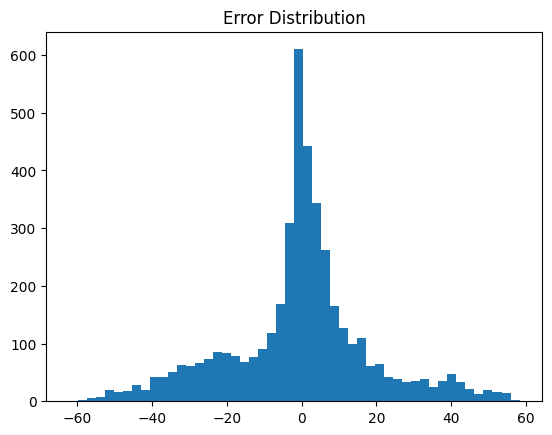

In [10]:
import matplotlib.pyplot as plt

errors = y_test - model.predict(X_test)

plt.hist(errors, bins=50)
plt.title("Error Distribution")
plt.show()

In [11]:
import pandas as pd

xgb_model = model.named_steps["model"]

feature_importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importances.head(10)

,feature,importance
32,sensor_4_mean,0.378060
46,sensor_11_mean,0.194960
54,sensor_15_mean,0.164160
28,sensor_2_mean,0.034140
38,sensor_7_mean,0.028517
13,sensor_9,0.028068
1,cycles,0.021746
42,sensor_9_mean,0.018567
30,sensor_3_mean,0.017421
58,sensor_17_mean,0.016389


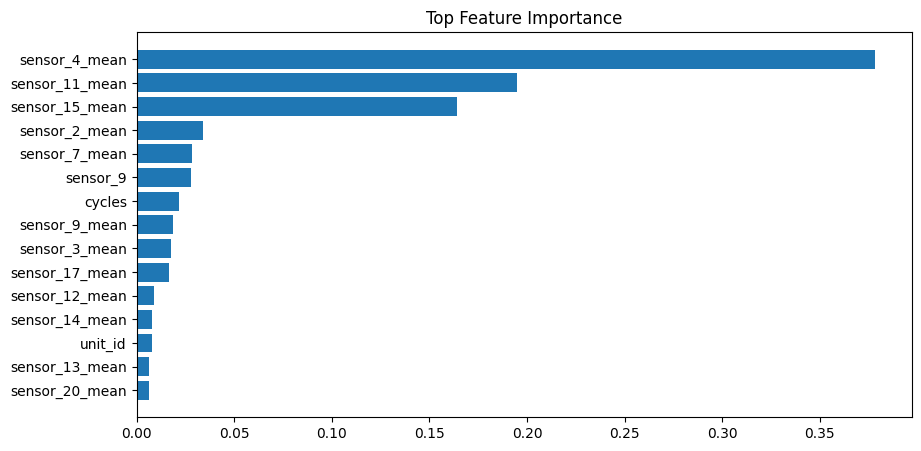

In [15]:
import matplotlib.pyplot as plt

top_features = feature_importances.head(15)

plt.figure(figsize=[10, 5])
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top Feature Importance")
plt.show()